In [36]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [37]:
df = pd.read_csv('ml_dataset_50-50_14-10-2025.csv')

print(f"\nDataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['attack'].value_counts())
print(f"\nAttack ratio: {df['attack'].sum() / len(df) * 100:.2f}%")


Dataset shape: (3414, 69)

Class distribution:
attack
0    2656
1     758
Name: count, dtype: int64

Attack ratio: 22.20%


In [38]:
X = df.drop(['timestamp', 'attack'], axis=1)
y = df['attack']

print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {list(X.columns)}")

Number of features: 67
Feature names: ['flow_packet_count_sum', 'flow_packet_count_mean', 'flow_packet_count_std', 'flow_byte_count_sum', 'flow_byte_count_mean', 'flow_byte_count_std', 'flow_duration_sec_mean', 'flow_duration_sec_std', 'port_rx_packets_sum', 'port_rx_packets_mean', 'port_rx_packets_std', 'port_tx_packets_sum', 'port_tx_packets_mean', 'port_tx_packets_std', 'port_rx_bytes_sum', 'port_rx_bytes_mean', 'port_rx_bytes_std', 'port_tx_bytes_sum', 'port_tx_bytes_mean', 'port_tx_bytes_std', 'port_rx_dropped_sum', 'port_rx_dropped_mean', 'port_rx_dropped_std', 'port_tx_errors_sum', 'port_tx_errors_mean', 'port_tx_errors_std', 'table_active_count_sum', 'table_active_count_mean', 'table_active_count_std', 'table_lookup_count_sum', 'table_lookup_count_mean', 'table_lookup_count_std', 'table_matched_count_sum', 'table_matched_count_mean', 'table_matched_count_std', 'no_of_tcp_flows', 'no_of_udp_flows', 'no_of_icmp_flows', 'no_of_other_flows', 'no_of_total_flows', 'no_of_unique_src_a

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set attack ratio: {y_train.sum() / len(y_train) * 100:.2f}%")
print(f"Test set attack ratio: {y_test.sum() / len(y_test) * 100:.2f}%")

Training set size: 2731
Test set size: 683
Training set attack ratio: 22.19%
Test set attack ratio: 22.25%


In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
rf_model = RandomForestClassifier(
    n_estimators=100,          # Number of trees
    max_depth=20,              # Maximum depth of trees
    min_samples_split=5,       # Minimum samples to split a node
    min_samples_leaf=2,        # Minimum samples at leaf node
    max_features='sqrt',       # Number of features to consider for split
    random_state=42,
    n_jobs=-1,                 # Use all CPU cores
    class_weight='balanced',   # Handle class imbalance
    verbose=1
)

rf_model.fit(X_train_scaled, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=5, n_jobs=-1,
                       random_state=42, verbose=1)

In [42]:
# Predictions
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


In [43]:
# Evaluate
print("Model evaluation")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

Model evaluation

Accuracy: 0.9195
Precision: 0.7939
Recall: 0.8618
F1-Score: 0.8265
ROC-AUC Score: 0.9540
Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.94      0.95       531
      Attack       0.79      0.86      0.83       152

    accuracy                           0.92       683
   macro avg       0.88      0.90      0.89       683
weighted avg       0.92      0.92      0.92       683

Confusion Matrix:
[[497  34]
 [ 21 131]]

True Negatives: 497
False Positives: 34
False Negatives: 21
True Positives: 131


In [44]:
print("Feature importance analysis:")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

Feature importance analysis:

Top 15 Most Important Features:
                     feature  importance
      no_of_unique_src_ports    0.113656
             no_of_tcp_flows    0.079002
            tcp_to_udp_ratio    0.073580
           no_of_total_flows    0.051407
     table_active_count_mean    0.042666
      flow_duration_sec_mean    0.037506
             total_flows_10s    0.037358
        flow_byte_count_mean    0.036445
      table_active_count_sum    0.029347
       flow_packets_per_flow    0.027352
      flow_packet_count_mean    0.025406
      table_active_count_std    0.023630
  flow_packet_count_10s_mean    0.020366
unique_src_to_dst_port_ratio    0.020128
    flow_byte_count_10s_mean    0.019621


Text(0.5, 611.5833333333334, 'Predicted')

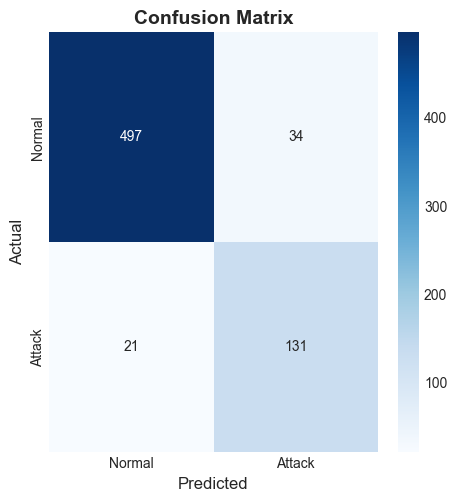

In [45]:
# Visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig = plt.figure(figsize=(18, 12))

# 1. Confusion Matrix Heatmap
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

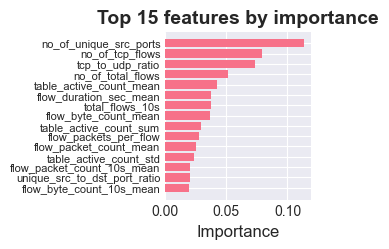

In [46]:
# 2. Feature Importance (Top 15)
ax2 = plt.subplot(2, 3, 2)
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'], fontsize=8)
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 features by importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

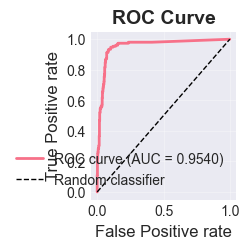

In [47]:
# 3. ROC Curve
ax3 = plt.subplot(2, 3, 3)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive rate', fontsize=12)
plt.ylabel('True Positive rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

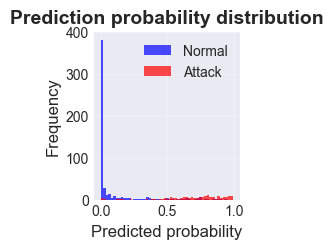

In [48]:
# 4. Prediction distribution
ax4 = plt.subplot(2, 3, 4)
plt.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.7, label='Normal', color='blue')
plt.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.7, label='Attack', color='red')
plt.xlabel('Predicted probability', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Prediction probability distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

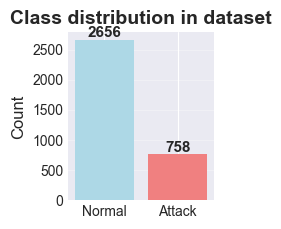

In [49]:
# 5. Class distribution
ax5 = plt.subplot(2, 3, 5)
class_counts = y.value_counts()
plt.bar(['Normal', 'Attack'], class_counts.values, color=['lightblue', 'lightcoral'])
plt.ylabel('Count', fontsize=12)
plt.title('Class distribution in dataset', fontsize=14, fontweight='bold')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

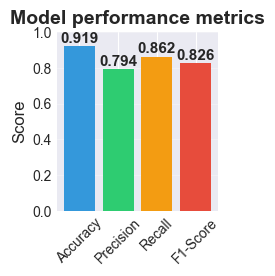

In [50]:
# 6. Model performance metrics
ax6 = plt.subplot(2, 3, 6)
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred)
}
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = plt.bar(metrics.keys(), metrics.values(), color=colors)
plt.ylim(0, 1)
plt.ylabel('Score', fontsize=12)
plt.title('Model performance metrics', fontsize=14, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [51]:
# Save the model and scaler
# import joblib
# joblib.dump(rf_model, 'rf_model.pkl')
# joblib.dump(scaler, 'scaler.pkl')
# print("Model saved as 'rf_model.pkl'")
# print("Scaler saved as 'scaler.pkl'")

# feature_importance.to_csv('feature_importance.csv', index=False)